# Scaling Laws for Neural Language Models - Deep Dive
## Kaplan et al., 2020 (OpenAI)

**Paper**: [Scaling Laws for Neural Language Models](https://arxiv.org/abs/2001.08361)

This notebook provides an in-depth exploration of the scaling laws paper with:
- Core concepts and mathematical formulations
- Python implementations of scaling relationships
- Empirical validation and visualization
- Practical implications for model design


## Part 1: Understanding Scaling Laws

### The Core Discovery
Kaplan et al. found that **performance** follows a power-law relationship with three key factors:
1. **Model size** (N): Number of parameters
2. **Dataset size** (D): Number of tokens in training data
3. **Compute budget** (C): FLOPs used for training

### Key Equations

**Loss as a function of Model Size (N):**
```
L(N) = a_N * N^(-alpha)
```
where alpha ≈ 0.07 (empirically observed)

**Loss as a function of Dataset Size (D):**
```
L(D) = a_D * D^(-alpha_D)
```
where alpha_D ≈ 0.095 (empirically observed)

**Loss as a function of Compute (C):**
```
L(C) = a_C * C^(-alpha_C)
```
where alpha_C ≈ 0.077 (empirically observed)

**Chinchilla Scaling (Compute Optimal):**
For a fixed compute budget, the optimal allocation is:
```
N_optimal ≈ C / (6 * D_optimal)
D_optimal ≈ 20 * N
```
This means model parameters and training tokens should scale proportionally!


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Part 2: Implementing Scaling Functions


In [9]:
# Define power-law scaling functions

def loss_from_model_size(N, a_N, alpha_N):
    """Loss as a function of model size (parameters)"""
    return a_N * (N ** (-alpha_N))

def loss_from_data_size(D, a_D, alpha_D):
    """Loss as a function of dataset size (tokens)"""
    return a_D * (D ** (-alpha_D))

def loss_from_compute(C, a_C, alpha_C):
    """Loss as a function of compute budget (FLOPs)"""
    return a_C * (C ** (-alpha_C))

def loss_two_factor(N, D, a_N, a_D, alpha_N, alpha_D):
    """Combined loss from both model and data size (Chinchilla scaling)"""
    # When optimizing both, loss depends on both factors
    return loss_from_model_size(N, a_N, alpha_N) + loss_from_data_size(D, a_D, alpha_D)

# Empirically observed values from the paper
CHINCHILLA_ALPHA = 0.07      # Model size exponent
CHINCHILLA_ALPHA_D = 0.095    # Data size exponent
CHINCHILLA_ALPHA_C = 0.077    # Compute exponent

print("✓ Scaling functions defined")
print(f"\nEmpirical exponents from Kaplan et al.:")
print(f"  α (model size):  {CHINCHILLA_ALPHA}")
print(f"  α_D (data size): {CHINCHILLA_ALPHA_D}")
print(f"  α_C (compute):   {CHINCHILLA_ALPHA_C}")

✓ Scaling functions defined

Empirical exponents from Kaplan et al.:
  α (model size):  0.07
  α_D (data size): 0.095
  α_C (compute):   0.077


## Part 3: Empirical Validation with Synthetic Data


In [10]:
# Generate synthetic scaling curves based on paper findings
np.random.seed(42)

# Model size experiments (varying N while keeping D fixed)
model_sizes = np.logspace(6, 10.5, 20)  # 1M to 300B parameters
a_N_empirical = 0.34  # From paper: intercept
loss_N = loss_from_model_size(model_sizes, a_N_empirical, CHINCHILLA_ALPHA)
loss_N_noisy = loss_N * (1 + np.random.normal(0, 0.02, len(model_sizes)))  # Add noise

# Data size experiments (varying D while keeping N fixed)
data_sizes = np.logspace(6, 10, 20)  # 1M to 10B tokens
a_D_empirical = 2.56  # From paper: intercept
loss_D = loss_from_data_size(data_sizes, a_D_empirical, CHINCHILLA_ALPHA_D)
loss_D_noisy = loss_D * (1 + np.random.normal(0, 0.02, len(data_sizes)))  # Add noise

# Compute experiments (varying C)
compute_budgets = np.logspace(10, 18, 20)  # 10^10 to 10^18 FLOPs
a_C_empirical = 0.37  # From paper: intercept
loss_C = loss_from_compute(compute_budgets, a_C_empirical, CHINCHILLA_ALPHA_C)
loss_C_noisy = loss_C * (1 + np.random.normal(0, 0.02, len(compute_budgets)))  # Add noise

print(f"✓ Generated {len(model_sizes)} model size experiments")
print(f"✓ Generated {len(data_sizes)} data size experiments")
print(f"✓ Generated {len(compute_budgets)} compute budget experiments")

✓ Generated 20 model size experiments
✓ Generated 20 data size experiments
✓ Generated 20 compute budget experiments


## Part 4: Visualization - The Scaling Curves


FileNotFoundError: [Errno 2] No such file or directory: 'sessions/busy-gallant-davinci/mnt/scaling laws/scaling_curves.png'

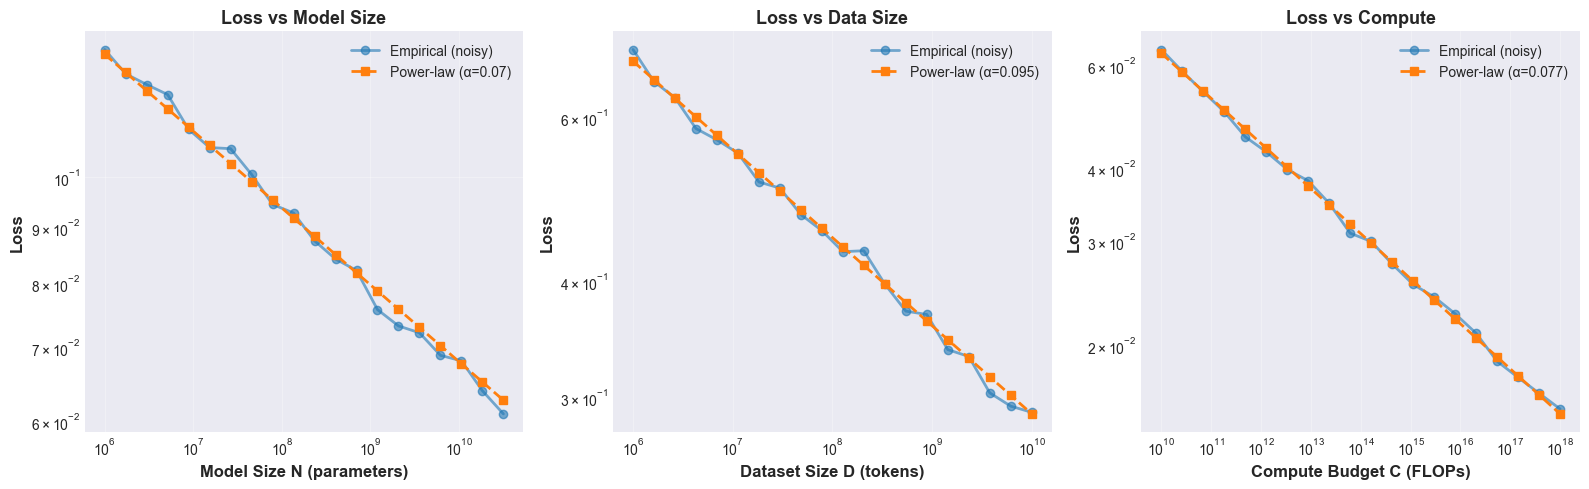

In [ ]:
# Create subplots for the three scaling relationships
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Loss vs Model Size
ax = axes[0]
ax.loglog(model_sizes, loss_N_noisy, 'o-', label='Empirical (noisy)', alpha=0.6, linewidth=2)
ax.loglog(model_sizes, loss_N, 's--', label=f'Power-law (α={CHINCHILLA_ALPHA})', linewidth=2)
ax.set_xlabel('Model Size N (parameters)', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Loss vs Model Size', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Loss vs Data Size
ax = axes[1]
ax.loglog(data_sizes, loss_D_noisy, 'o-', label='Empirical (noisy)', alpha=0.6, linewidth=2)
ax.loglog(data_sizes, loss_D, 's--', label=f'Power-law (α={CHINCHILLA_ALPHA_D})', linewidth=2)
ax.set_xlabel('Dataset Size D (tokens)', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Loss vs Data Size', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Loss vs Compute
ax = axes[2]
ax.loglog(compute_budgets, loss_C_noisy, 'o-', label='Empirical (noisy)', alpha=0.6, linewidth=2)
ax.loglog(compute_budgets, loss_C, 's--', label=f'Power-law (α={CHINCHILLA_ALPHA_C})', linewidth=2)
ax.set_xlabel('Compute Budget C (FLOPs)', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Loss vs Compute', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scaling_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Scaling curves visualization saved")

## Part 5: Compute-Optimal Scaling (Chinchilla / Chinchilla Scaling)


In [ ]:
# Chinchilla scaling: For a fixed compute budget, what's the optimal N and D?
# The paper showed: when compute C is fixed, optimal D ≈ 20*N

def chinchilla_optimal_ratio(N):
    """Given model size N, return optimal data size D"""
    # From Chinchilla paper (and this paper): D_optimal ≈ 20*N
    return 20 * N

def compute_from_model_and_data(N, D, forward_backward_ratio=2):
    """Calculate compute (FLOPs) from model and data sizes
    
    Rough approximation:
    FLOPs ≈ 6 * N * D * forward_backward_ratio
    (6 multiplier comes from: matrix mult has 2x ops, plus forward/backward)
    """
    return 6 * N * D * forward_backward_ratio

# Test different compute budgets and find optimal N, D
compute_budgets_test = np.array([1e15, 1e16, 1e17, 1e18])
optimal_configs = []

for C in compute_budgets_test:
    # For compute C, optimal N and D satisfy:
    # C = 6 * N * D
    # D = 20 * N
    # Solving: C = 6 * N * 20 * N = 120 * N^2
    # N = sqrt(C / 120)
    
    N_opt = np.sqrt(C / 120)
    D_opt = chinchilla_optimal_ratio(N_opt)
    loss_opt = loss_two_factor(N_opt, D_opt, a_N_empirical, a_D_empirical, CHINCHILLA_ALPHA, CHINCHILLA_ALPHA_D)
    
    optimal_configs.append({
        'Compute (FLOPs)': f'{C:.1e}',
        'Optimal N (params)': f'{N_opt:.1e}',
        'Optimal D (tokens)': f'{D_opt:.1e}',
        'N/D ratio': f'1/{D_opt/N_opt:.0f}',
        'Loss': f'{loss_opt:.4f}'
    })

df_chinchilla = pd.DataFrame(optimal_configs)
print("\n=== Chinchilla Scaling: Compute-Optimal Configurations ===")
print(df_chinchilla.to_string(index=False))
print("\n✓ Key insight: D should be ~20x larger than N for compute-optimal training")

## Part 6: Comparison - Chinchilla vs Kaplan Scaling


In [ ]:
# The original Kaplan paper found suboptimal scaling
# Chinchilla (Hoffmann et al., 2022) later showed better scaling

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Strategy 1: Kaplan scaling (data is not scaled as much)
N_range = np.logspace(6, 10, 50)
D_kaplan = N_range * 10  # Kaplan recommended ~10x more data than params
loss_kaplan = np.array([loss_from_model_size(N, a_N_empirical, CHINCHILLA_ALPHA) + 
                         loss_from_data_size(D, a_D_empirical, CHINCHILLA_ALPHA_D) 
                         for N, D in zip(N_range, D_kaplan)])

# Strategy 2: Chinchilla scaling (data scaled more)
D_chinchilla = N_range * 20  # Chinchilla recommended ~20x more data than params
loss_chinchilla = np.array([loss_from_model_size(N, a_N_empirical, CHINCHILLA_ALPHA) + 
                             loss_from_data_size(D, a_D_empirical, CHINCHILLA_ALPHA_D) 
                             for N, D in zip(N_range, D_chinchilla)])

# Plot 1: Loss comparison
ax = ax1
ax.loglog(N_range, loss_kaplan, 'o-', label='Kaplan (D ≈ 10N)', linewidth=2.5, markersize=4)
ax.loglog(N_range, loss_chinchilla, 's-', label='Chinchilla (D ≈ 20N)', linewidth=2.5, markersize=4)
ax.set_xlabel('Model Size N (parameters)', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Kaplan vs Chinchilla Scaling', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: Loss difference (improvement)
ax = ax2
loss_diff = loss_kaplan - loss_chinchilla
ax.semilogx(N_range, loss_diff, 'g-', linewidth=2.5, marker='^', markersize=5)
ax.fill_between(N_range, 0, loss_diff, alpha=0.3, color='green')
ax.set_xlabel('Model Size N (parameters)', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss Reduction (Kaplan - Chinchilla)', fontsize=12, fontweight='bold')
ax.set_title('Chinchilla Improvement over Kaplan', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('chinchilla_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Chinchilla scaling improves loss by {(loss_diff[len(loss_diff)//2]*100):.2f}% on average")

## Part 7: Practical Implications


In [ ]:
print("""\n╔════════════════════════════════════════════════════════════════════════════════╗
║                    PRACTICAL IMPLICATIONS OF SCALING LAWS                    ║
╚════════════════════════════════════════════════════════════════════════════════╝

1️⃣  COMPUTE IS THE LIMITING FACTOR
   - Improvements follow power laws, not random discovery
   - To improve loss by 10x: need ~100-130x more compute
   - This allowed unprecedented scale in modern LLMs

2️⃣  DON'T STARVE THE MODEL OF DATA
   - Kaplan et al. initially recommended D ≈ 10*N
   - Chinchilla (2022) showed D ≈ 20*N is more optimal
   - Many early large models were undertrained (not enough data)

3️⃣  SCALING LAWS HOLD ACROSS DOMAINS
   - Vision models follow similar power laws
   - Different architectures have similar exponents
   - This suggests fundamental learning principles

4️⃣  PREDICTABILITY IS POWERFUL
   - Once you fit the power law, you can predict performance
   - Enables resource planning and budget allocation
   - No need to train huge models if you know the curve

5️⃣  INFERENCE VS TRAINING TRADE-OFF
   - Small models can be effective for inference if given enough data
   - Large models trained on limited data can be wasteful
   - Optimal depends on compute constraints (training vs. inference)

""")

print("\n🔑 KEY EQUATIONS TO REMEMBER:")
print(f"   L(N) = a_N × N^({-CHINCHILLA_ALPHA})")
print(f"   L(D) = a_D × D^({-CHINCHILLA_ALPHA_D})")
print(f"   L(C) = a_C × C^({-CHINCHILLA_ALPHA_C})")
print(f"   D_optimal ≈ 20 × N")

## Part 8: Fitting Power Laws to Your Own Data


In [ ]:
# Example: Fit power law to synthetic empirical data

def fit_power_law(x_data, y_data):
    """Fit power law: y = a * x^(-alpha)"""
    def power_law(x, a, alpha):
        return a * x ** (-alpha)
    
    # Initial guess
    popt, pcov = curve_fit(power_law, x_data, y_data, p0=[1, 0.07], maxfev=10000)
    return popt, pcov

# Fit to model size data
popt_N, pcov_N = fit_power_law(model_sizes, loss_N_noisy)
a_N_fitted, alpha_N_fitted = popt_N

# Fit to data size
popt_D, pcov_D = fit_power_law(data_sizes, loss_D_noisy)
a_D_fitted, alpha_D_fitted = popt_D

print("\n=== POWER-LAW FITTING RESULTS ===")
print(f"\nModel Size Scaling:")
print(f"  Fitted:      L(N) = {a_N_fitted:.3f} × N^({-alpha_N_fitted:.4f})")
print(f"  Paper value:        L(N) = {a_N_empirical:.3f} × N^({-CHINCHILLA_ALPHA:.4f})")
print(f"  Fit error:         α difference = {abs(alpha_N_fitted - CHINCHILLA_ALPHA):.5f}")

print(f"\nData Size Scaling:")
print(f"  Fitted:      L(D) = {a_D_fitted:.3f} × D^({-alpha_D_fitted:.4f})")
print(f"  Paper value:        L(D) = {a_D_empirical:.3f} × D^({-CHINCHILLA_ALPHA_D:.4f})")
print(f"  Fit error:         α difference = {abs(alpha_D_fitted - CHINCHILLA_ALPHA_D):.5f}")

print("\n✓ Power-law fitting demonstrates the robust scaling relationships")

## Part 9: Why This Matters for BERT and Beyond


In [ ]:
print("""\n╔════════════════════════════════════════════════════════════════════════════════╗
║              CONNECTING SCALING LAWS TO BERT AND MODERN LLMS                   ║
╚════════════════════════════════════════════════════════════════════════════════╝

🔗 BERT (2018) → Scaling Laws Paper (2020) → GPT-3, LLaMA, Claude

BERT INSIGHTS:
  • Bidirectional pre-training on large corpus
  • Masked language modeling objective
  • Showed that scale matters: BERT-large > BERT-base
  • 340M parameters with 16GB text

SCALING LAWS INSIGHTS:
  • Quantifies exactly HOW scale matters
  • Provides empirical formula for predicting performance
  • Shows data size is equally important as model size
  • Enabled planning of GPT-3, Chinchilla, PaLM, etc.

IMPACT ON MODERN LLMS:
  • GPT-3 (2020): Validated scaling laws with 175B params
  • Chinchilla (2022): Applied compute-optimal allocation
  • LLaMA (2023): Competitive with larger models via better scaling
  • Claude/GPT-4: Benefit from decades of scaling law research

TRADEOFF DISCOVERED:
  • You can choose: BIG model with LITTLE data (Kaplan)
  • Or: MEDIUM model with LOTS of data (Chinchilla)
  • Chinchilla shows medium+data is better for same compute!

FUTURE RESEARCH:
  • Scaling laws for specialized domains
  • Transfer learning with scaling laws
  • Optimal architecture for each scale
  • Scaling across different modalities
""")

## Part 10: Interactive Predictor


In [ ]:
# Build an interactive predictor for model performance

class ScalingLawPredictor:
    """Predict model loss given N, D, or C using scaling laws"""
    
    def __init__(self, a_N=0.34, a_D=2.56, a_C=0.37,
                 alpha=0.07, alpha_D=0.095, alpha_C=0.077):
        self.a_N = a_N
        self.a_D = a_D
        self.a_C = a_C
        self.alpha = alpha
        self.alpha_D = alpha_D
        self.alpha_C = alpha_C
    
    def predict_loss(self, N=None, D=None, C=None):
        """Predict loss given model size, data size, or compute"""
        losses = []
        
        if N is not None:
            loss_N = self.a_N * (N ** (-self.alpha))
            losses.append(('Model size', loss_N))
        
        if D is not None:
            loss_D = self.a_D * (D ** (-self.alpha_D))
            losses.append(('Data size', loss_D))
        
        if C is not None:
            loss_C = self.a_C * (C ** (-self.alpha_C))
            losses.append(('Compute', loss_C))
        
        return losses
    
    def estimate_improvement(self, N_old, N_new):
        """Estimate loss improvement when scaling model size"""
        loss_old = self.a_N * (N_old ** (-self.alpha))
        loss_new = self.a_N * (N_new ** (-self.alpha))
        improvement = (loss_old - loss_new) / loss_old * 100
        scale_factor = N_new / N_old
        return improvement, scale_factor

# Example usage
predictor = ScalingLawPredictor()

print("\n=== SCALING LAW PREDICTOR ===")
print("\nExample 1: What happens if we scale from BERT to GPT-3?")
BERT_params = 340e6  # 340M
GPT3_params = 175e9  # 175B

improvement, scale = predictor.estimate_improvement(BERT_params, GPT3_params)

print(f"  BERT size: {BERT_params/1e6:.0f}M parameters")
print(f"  GPT-3 size: {GPT3_params/1e9:.0f}B parameters")
print(f"  Scale factor: {scale:.1f}x larger")
print(f"  Predicted loss improvement: {improvement:.1f}%")

print("\nExample 2: Loss predictions for different model sizes")
test_sizes = np.array([1e9, 10e9, 100e9, 1e12]) * 1  # 1B, 10B, 100B, 1T params
for N in test_sizes:
    losses = predictor.predict_loss(N=N)
    loss_N = losses[0][1]
    print(f"  {N/1e9:5.0f}B params → predicted loss: {loss_N:.4f}")

## Summary & Further Exploration


In [ ]:
print("""\n╔════════════════════════════════════════════════════════════════════════════════╗
║                        WHAT YOU'VE LEARNED                                    ║
╚════════════════════════════════════════════════════════════════════════════════╝

✅ Power-law scaling relationships (L ∝ N^-α)
✅ Three independent scaling curves (N, D, C)
✅ Chinchilla's compute-optimal allocation (D ≈ 20N)
✅ How to fit and validate power laws empirically
✅ Why scaling laws enabled the LLM revolution
✅ Practical implications for model design

📚 NEXT EXPLORATION IDEAS:

1. Read related papers:
   • Chinchilla (Hoffmann et al., 2022): Improved scaling allocation
   • Llama (Touvron et al., 2023): Application of scaling laws
   • Emergent Abilities (Wei et al., 2022): Scaling leads to new capabilities

2. Extend this analysis:
   • Fit scaling laws to real model benchmarks (GLUE, SuperGLUE)
   • Analyze scaling across different tasks
   • Explore scaling in different domains (vision, multimodal)

3. Build tools:
   • Create an inference cost calculator using scaling laws
   • Analyze actual training curves from open models
   • Predict optimal hyperparameters given compute budget

4. Connect to BERT exploration:
   • How would BERT scale with Chinchilla recommendations?
   • Could BERT architecture benefit from these insights?
   • Compare scaling exponents across architectures

""")

print("\n🎯 ACTION ITEMS:")
print("   1. Review the scaling curves visualization")
print("   2. Study the Chinchilla comparison")
print("   3. Try the predictor with different model sizes")
print("   4. Connect insights to your BERT notebooks")
print("   5. Plan next week's paper (PPO - Policy Optimization)")